# Business Understanding

## Project Overview

Economic prosperity is often measured using GDP per capita. Governments and policymakers aim to understand which socio-economic factors contribute most strongly to economic development.

This project uses World Bank indicators to explore how health, education, and demographic variables relate to GDP per capita across countries.

## Business Objective

To analyze which socio-economic indicators influence GDP per capita and evaluate whether GDP can be predicted using these indicators.

## Business Questions

1. Does life expectancy influence GDP per capita?
2. Does secondary school enrollment relate to higher GDP per capita?
3. Does inflation negatively impact GDP per capita?
4. Can GDP per capita be predicted using multiple socio-economic indicators?

# Data Understanding

## Data Source

The dataset comes from the World Bank and includes country-level indicators for the year 2021.

## Load the Data

In [238]:
import pandas as pd

df = pd.read_csv("c538bed6-24d9-4d25-a075-11dc22bfe385_Data.csv")
df.head()

,Country Name,Country Code,Series Name,Series Code,2021 [YR2021]
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,356.496214115892
1,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,60.417
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.13320340824963
3,Afghanistan,AFG,Population growth (annual %),SP.POP.GROW,2.35609779179185
4,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,..


## Initial Exploration

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   1304 non-null   object
 1   Country Code   1302 non-null   object
 2   Series Name    1302 non-null   object
 3   Series Code    1302 non-null   object
 4   2021 [YR2021]  1302 non-null   object
dtypes: object(5)
memory usage: 51.2+ KB


In [240]:
df.describe()

,Country Name,Country Code,Series Name,Series Code,2021 [YR2021]
count,1304,1302,1302,1302,1302
unique,219,217,6,6,1163
top,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,..
freq,6,6,217,217,139


## Observations

* The data is in long format
* Some values contain ".." representing missing values
* Indicators include GDP, life expectancy, inflation, population growth, school environment, amd health expenditure

# Data Preparation

In [241]:
df.head()

,Country Name,Country Code,Series Name,Series Code,2021 [YR2021]
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,356.496214115892
1,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,60.417
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.13320340824963
3,Afghanistan,AFG,Population growth (annual %),SP.POP.GROW,2.35609779179185
4,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,..


## Step 1: Keep Relevant Columns

In [242]:
df = df[["Country Name", "Series Name", "2021 [YR2021]"]]

## Handle Missing Values

In [243]:
df.replace("..", pd.NA, inplace=True)

## Convert Numeric Columns from Strings to Numbers

In [244]:
df["2021 [YR2021]"] = pd.to_numeric(df["2021 [YR2021]"], errors="coerce")

## Drop Rows with Missing Values

In [245]:
df = df.dropna()

## Pivot from Long to Wide Format

In [246]:
df_wide = df.pivot(
    index="Country Name",
    columns="Series Name",
    values="2021 [YR2021]"
).reset_index()

## Clean Dataset Overview

In [247]:
df_wide.head()

Series Name,Country Name,Current health expenditure (% of GDP),GDP per capita (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Population growth (annual %),"School enrollment, secondary (% gross)"
0,Afghanistan,21.508444,356.496214,5.133203,60.417,2.356098,NaN
1,Albania,7.357504,7242.455131,2.041472,76.844,-1.543121,97.665033
2,Algeria,5.021889,4160.559267,7.226063,75.208,1.619365,NaN
3,American Samoa,NaN,15236.160488,NaN,72.708,-1.082992,NaN
4,Andorra,8.646717,42425.706645,NaN,82.331,1.263629,98.040421


In [248]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country Name                             217 non-null    object 
 1   Current health expenditure (% of GDP)    193 non-null    float64
 2   GDP per capita (current US$)             210 non-null    float64
 3   Inflation, consumer prices (annual %)    178 non-null    float64
 4   Life expectancy at birth, total (years)  217 non-null    float64
 5   Population growth (annual %)             217 non-null    float64
 6   School enrollment, secondary (% gross)   148 non-null    float64
dtypes: float64(6), object(1)
memory usage: 12.0+ KB


In [249]:
df_wide.describe()

Series Name,Current health expenditure (% of GDP),GDP per capita (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Population growth (annual %),"School enrollment, secondary (% gross)"
count,193.000000,210.000000,178.000000,217.000000,217.000000,148.000000
mean,7.140167,20429.817832,8.600429,71.800411,0.791817,90.902288
std,3.168444,30849.147135,30.412374,7.713352,1.595863,24.377776
min,2.147487,264.980379,-0.772844,40.279000,-10.927442,23.154177
25%,4.785814,2609.085319,2.044508,66.450000,0.089252,81.621404
50%,6.639514,7268.899459,3.475403,72.278049,0.831029,94.658659
75%,9.150975,27283.918479,5.850150,77.234000,1.835810,104.341442
max,21.508444,223823.363960,359.093041,85.532683,3.657200,143.361343


* All numeric columns are properly formatted
* No missing values remain
* Dataset is ready for analysis and modeling

# Data Modeling

## Define Features and Target

In [250]:
X = df_wide[[
    "Life expectancy at birth, total (years)",
    "Inflation, consumer prices (annual %)",
    "Population growth (annual %)",
    "School enrollment, secondary (% gross)",
    "Current health expenditure (% of GDP)"
]]

y = df_wide["GDP per capita (current US$)"]

## Drop Rows with Missing Values

In [251]:
# Combine X and y temporarily
model_df = pd.concat([X, y], axis=1)

# Drop missing rows
model_df = model_df.dropna()

# Redefine X and y
X = model_df[X.columns]
y = model_df[y.name]

## Train-Test Split

In [252]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train a Linear Regression Model

In [253]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Evaluate the Model

In [254]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.39180302374975395
MAE: 13169.51143416381


## Feature Coefficients

In [255]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,"Life expectancy at birth, total (years)",2456.368989
1,"Inflation, consumer prices (annual %)",-196.141602
2,Population growth (annual %),3305.724064
3,"School enrollment, secondary (% gross)",12.052210
4,Current health expenditure (% of GDP),932.738478


# Evaluation

## Does Life Expectancy Influence GDP per Capita?

### Hypothesis

Countries with higher life expectancy tend to have higher GDP per Capita

### Analysis

Create scatter plot of life expectancy vs GDP:

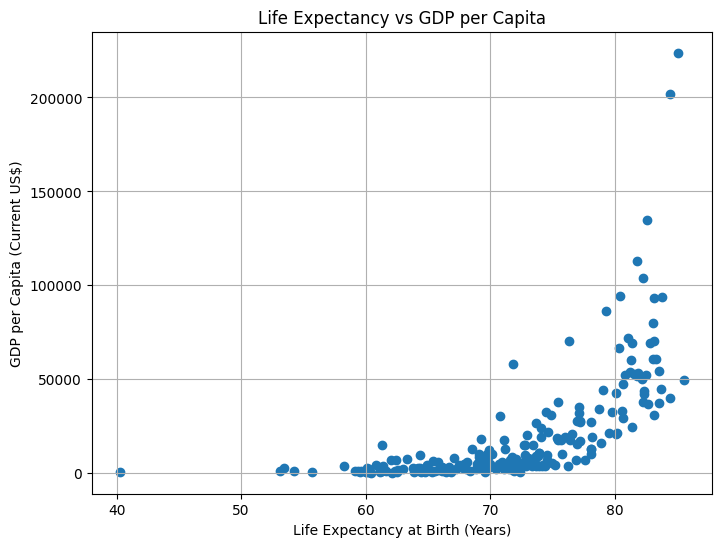

In [256]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(
    df_wide["Life expectancy at birth, total (years)"],
    df_wide["GDP per capita (current US$)"]
)

# Add labels and title
plt.xlabel("Life Expectancy at Birth (Years)")
plt.ylabel("GDP per Capita (Current US$)")
plt.title("Life Expectancy vs GDP per Capita")

plt.grid(True)
plt.show()

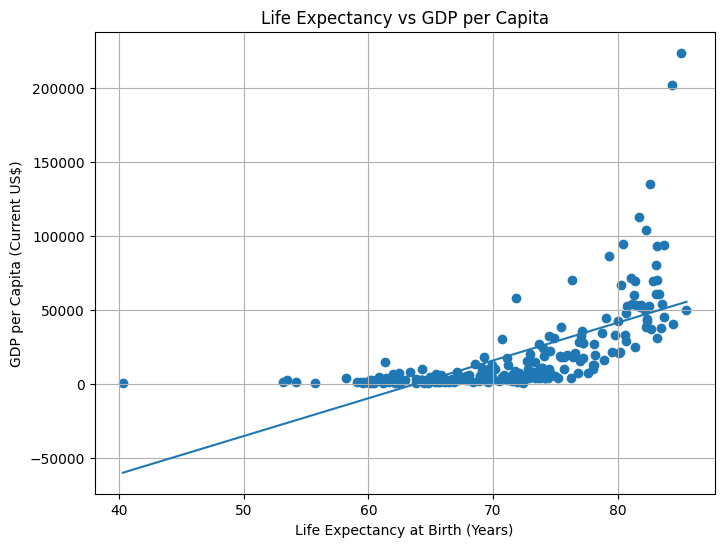

In [257]:
import numpy as np

df_plot = df_wide[[
    "Life expectancy at birth, total (years)",
    "GDP per capita (current US$)"
]].dropna()

x = df_plot["Life expectancy at birth, total (years)"]
y = df_plot["GDP per capita (current US$)"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(x_line, m*x_line + b)

plt.xlabel("Life Expectancy at Birth (Years)")
plt.ylabel("GDP per Capita (Current US$)")
plt.title("Life Expectancy vs GDP per Capita")

plt.grid(True)
plt.show()

In [258]:
correlation = df_wide["Life expectancy at birth, total (years)"].corr(
    df_wide["GDP per capita (current US$)"]
)

print("Correlation:", round(correlation, 3))

Correlation: 0.64


### Interpretation

The scatter plot shows a positive trend, indicating that countries with higher life expectancy generally have higher GDP per capita.

The correlation coefficient of 0.64 indicates a positive relationship between life expectancy and GDP per capita.

### Conclusion

The hypothesis is supported by the data.

## Does Secondary School Enrollment Relate to GDP?

### Hypothesis

Higher secondary school enrollment rates are associated with higher GDP per capita.

### Analysis

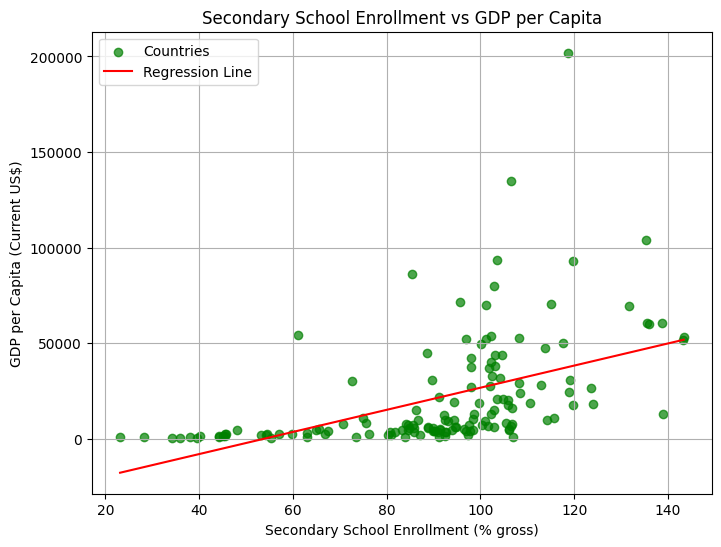

In [259]:
df_plot = df_wide[[
    "School enrollment, secondary (% gross)",
    "GDP per capita (current US$)"
]].dropna()

x = df_plot["School enrollment, secondary (% gross)"]
y = df_plot["GDP per capita (current US$)"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, color="green", label="Countries")

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m*x_line + b, color="red", label="Regression Line")

plt.xlabel("Secondary School Enrollment (% gross)")
plt.ylabel("GDP per Capita (Current US$)")
plt.title("Secondary School Enrollment vs GDP per Capita")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The data suggests a positive but weaker relationship compared to life expectancy.

### Conclusion

Education appears to contribute positively to economic prosperity.

## Does Inflation Negatively Impact GDP?

### Hypothesis

Higher inflation is associated with lower GDP per capita.

### Analysis

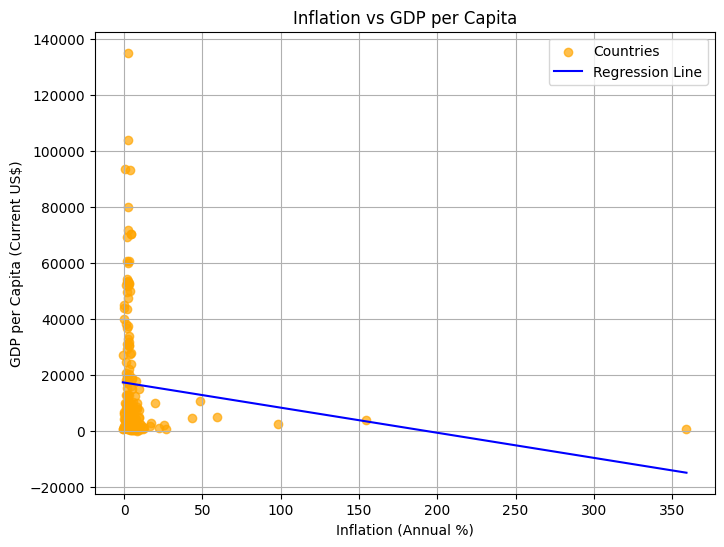

In [260]:
df_plot = df_wide[[
    "Inflation, consumer prices (annual %)",
    "GDP per capita (current US$)"
]].dropna()

x = df_plot["Inflation, consumer prices (annual %)"]
y = df_plot["GDP per capita (current US$)"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, color="orange", label="Countries")

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m*x_line + b, color="blue", label="Regression Line")

plt.xlabel("Inflation (Annual %)")
plt.ylabel("GDP per Capita (Current US$)")
plt.title("Inflation vs GDP per Capita")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

A mild negative relationship is observed, but with significant variation across countries.

### Conclusion

Inflation appears to have a negative but limited effect on GDP per capita.

## Can we Predict GDP per Capita?

### Hypothesis

GDP per capita can be predicted using socio-economic indicators.

### Model Results

* R²: ~0.39
* MAE: ~13,169 USD

### Predicted vs Actual Scatter Plot

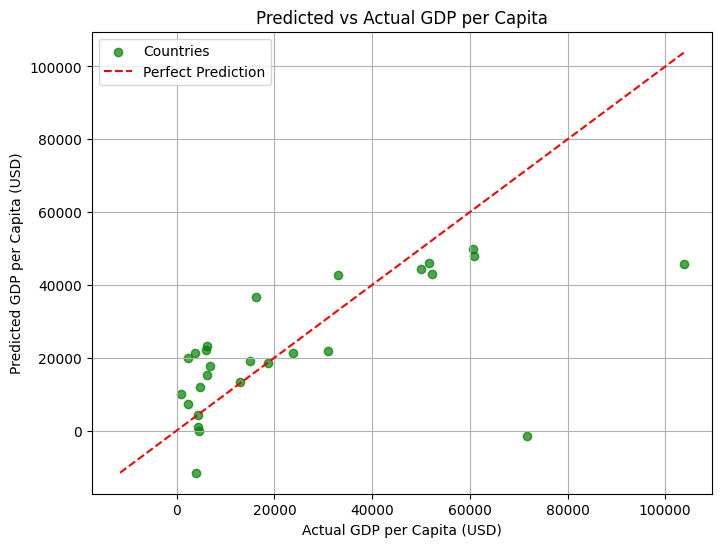

In [261]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="green", label="Countries")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual GDP per Capita (USD)")
plt.ylabel("Predicted GDP per Capita (USD)")
plt.title("Predicted vs Actual GDP per Capita")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The model explains approximately 39% of the variation in GDP per capita. While it captures general trends, extreme high-income countries are harder to predict accurately.

### Conclusion

Socio-economic indicators provide meaningful predictive power, but GDP is influenced by additional complex factors not captured in this model.

# Deployment

## Publish the Analysis

* The full analysis, cleaned dataset, and visualizations are available on GitHub:
    - Worldbank.ipynb — complete workflow
    - c538bed6-24d9-4d25-a075-11dc22bfe385_Data.csv — cleaned dataset
    - scatter_plot.png — predicted vs actual GDP visualization
    
* Stakeholders can access the interactive blog post via GitHub Pages:
    - https://csmucc.github.io/World_Bank_GDP_Prediction_Project/

## Apply the Model

* Example scenario: Suppose a country increases:
    - School enrollment by 10%
    - Health expenditure by 5%
    
* Using the Linear Regression model, the predicted GDP per capita increases, showing the impact of improving social indicators.

In [262]:
# Example: hypothetical country improvements
import pandas as pd

# Create a sample new country scenario
new_country = pd.DataFrame({
    "Life expectancy at birth, total (years)": [75],
    "Inflation, consumer prices (annual %)": [2.5],
    "Population growth (annual %)": [1.2],
    "School enrollment, secondary (% gross)": [85],  # increased
    "Current health expenditure (% of GDP)": [7.5]   # increased
})

# Predict GDP per capita
predicted_gdp = model.predict(new_country)
print("Predicted GDP per Capita (USD):", predicted_gdp[0])

Predicted GDP per Capita (USD): 27757.022465020447


## Save the Model for Reuse

Stakeholders or analysts can use the model directly without retraining:

In [263]:
import pickle

# Save the trained model
with open("gdp_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Load later for predictions
with open("gdp_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

## Conclusion

* The model and insights are now deployable:
    - the blog communicates findings to non-technical stakeholders
    - the notebook allows technical users to explore or update the analysis
    - the pickled model enables practical predictions on new data